# Indian Railway Train Delay Prediction

Welcome! This notebook will guide you step-by-step through building this project.

Let's start with **Step 1: Loading the Dataset and Dictionary**.

In [1]:
import os
import pandas as pd
import numpy as np

# 1. Update this path to where your dataset folder is located on your D: drive
DATA_DIRECTORY = r"D:\indian-railways-predict-train-delay"

# 2. Define the file paths
train_path = os.path.join(DATA_DIRECTORY, "ir_train.csv")
dict_path = os.path.join(DATA_DIRECTORY, "ir_data_dictionary.csv")

print("✅ Paths configured successfully!")

✅ Paths configured successfully!


### Reading the Data Dictionary
Let's load the dictionary file first. It contains descriptions of all columns in our dataset.

In [2]:
df_dict = pd.read_csv(dict_path)
df_dict

,column,type,description
0,journey_id,string,Unique journey ID (IR + 8 digits)
1,train_number,string,5-digit IR train number
2,train_type,category,"Type of train (Vande Bharat, Rajdhani, Mail, P..."
3,departure_date,date,Scheduled departure date (YYYY-MM-DD)
4,year,int,Year (2018–2024)
5,month,int,Month (1–12)
6,day_of_week,int,"Day of week (0=Monday, 6=Sunday)"
7,departure_hour,int,Scheduled departure hour (0–23)
8,is_weekend,binary,1 if Saturday or Sunday
9,is_night_departure,binary,1 if departure between 10pm and 4am


### Reading a Sample of the Training Data
Since `ir_train.csv` is 1.5 million rows, loading it fully might take a bit of memory.
Let's load just the first 5 rows first using `nrows=5` to see what the data looks like without using up RAM.

In [3]:
df_sample = pd.read_csv(train_path, nrows=5)
df_sample

,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1


### Step 1.5: Memory Optimization (Downcasting)

If we load the entire 1.5 million rows into memory, Pandas will default to using large data types (like `int64` and `float64`). 

We can save a huge amount of memory by "downcasting" them. For example:
- A column like `month` only has values `1` to `12`. Instead of using 8 bytes per number (`int64`), we can use 1 byte (`int8`).
- A column like `is_weekend` only has `0` or `1`. It can also be `int8`.

Let's write a function to do this automatically and load the entire dataset.

In [4]:
def optimize_memory(df):
    for col in df.columns:
        col_type = df[col].dtype
        
        # Only optimize numerical columns (skip text, string, or object columns)
        if pd.api.types.is_numeric_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            
            # If the column contains integers
            if str(col_type).startswith('int'):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            # If the column contains decimals (floats)
            else:
                # Downcast to float32 (saves 50% memory compared to float64)
                df[col] = df[col].astype(np.float32)
    return df

# Load the FULL dataset now
print("⏳ Loading full dataset... (this might take 10-15 seconds)")
df = pd.read_csv(train_path)

print(f"💾 Memory usage before optimization: {df.memory_usage().sum() / 1024**2:.2f} MB")
df = optimize_memory(df)
print(f"⚡ Memory usage after optimization: {df.memory_usage().sum() / 1024**2:.2f} MB")

⏳ Loading full dataset... (this might take 10-15 seconds)
💾 Memory usage before optimization: 514.98 MB
⚡ Memory usage after optimization: 216.01 MB


### Step 2: Visualizing Target Distribution

Now that the full dataset is loaded, let's explore our **target column (`is_delayed`)**.
We want to know: How many trains are delayed (`1`) vs on-time (`0`)?

--- Status Counts ---
is_delayed
1    1078329
0     421671
Name: count, dtype: int64


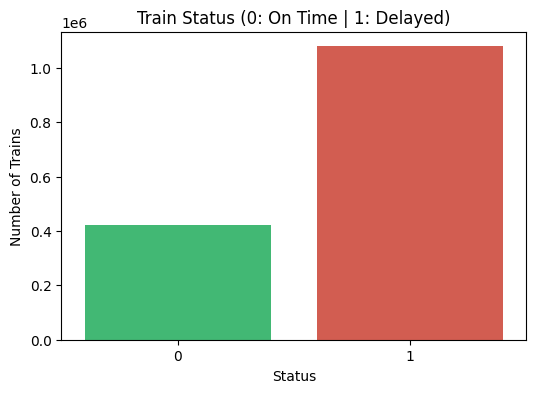

In [5]:
# Print the raw counts
print("--- Status Counts ---")
print(df['is_delayed'].value_counts())

# Plot the counts visually
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_delayed', hue='is_delayed', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Train Status (0: On Time | 1: Delayed)')
plt.xlabel('Status')
plt.ylabel('Number of Trains')
plt.show()

In [6]:
import pandas as pd
file_path = r"D:\indian-railways-predict-train-delay\ir_train.csv"

## PREPROCESSING


In [7]:
df = pd.read_csv(file_path)
df = optimize_memory(df)


In [8]:
print(f"shape of dataset -> {df.shape}")
print(f"Rows -> {df.shape[0]}")
print(f"Columns -> {df.shape[1]}")

shape of dataset -> (1500000, 45)
Rows -> 1500000
Columns -> 45


In [9]:
# missing values
missing = df.isnull().sum()
# print(missing.sum())
if(missing.sum() > 0):
    col_missing = missing[missing>0]
    print(col_missing)
else : 
    print("NO columns missing")

NO columns missing


In [10]:
# duplicates values
df.duplicated().sum()

np.int64(0)

In [11]:
# Missing Values
df.value_counts()

journey_id  train_number  train_type            departure_date  year  month  day_of_week  departure_hour  is_weekend  is_night_departure  is_peak_hour  is_festival_season  season       zone                              zone_abbr  source_station_category  destination_station_category  distance_km  num_scheduled_stops  scheduled_travel_hours  track_doubled  is_hdn_route  traction_type       is_electrified  psr_count  is_circular_route  is_monsoon_season  is_fog_risk  fog_risk_score  zone_fog_index  zone_congestion_index  season_severity_score  loco_age_years  coach_age_years  has_lhb_coaches  is_rake_shared  maintenance_score  seat_utilisation_pct  is_overloaded  late_incoming_rake  is_special_train  route_historical_ontime_pct  primary_delay_cause      delay_minutes  is_delayed
IR01717809  12536         Superfast Express     2023-09-18      2023  9      0            7               0           0                   1             0                   Monsoon      North Western Railway (NWR)

In [12]:
df.is_delayed.value_counts()

is_delayed
1    1078329
0     421671
Name: count, dtype: int64

# Step - 3 Numerical Feature Analysis

In [13]:
df.select_dtypes(include=np.number) 
# only grab columns that has whole numbers
numeric_df = df.select_dtypes(include = np.number)
# grabs decimals

In [14]:
numeric_df

,train_number,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,delay_minutes,is_delayed
0,12536,2023,9,0,7,0,0,1,0,620,...,0,1,5.5,88.800003,0,0,0,67.800003,110,1
1,12806,2020,4,3,8,0,0,1,0,1423,...,1,1,6.6,83.599998,0,0,0,57.000000,3,0
2,22416,2024,12,4,18,0,0,1,0,449,...,1,0,4.1,81.599998,0,0,0,81.800003,5,0
3,12250,2018,11,3,18,0,0,1,0,1443,...,1,0,5.5,82.099998,0,1,0,52.299999,135,1
4,74588,2020,6,3,5,0,0,0,0,219,...,0,1,8.0,58.299999,0,1,0,64.300003,154,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499995,12784,2020,4,3,1,0,1,0,1,879,...,1,0,6.7,66.099998,0,0,0,71.699997,1,0
1499996,74780,2018,1,1,18,0,0,1,0,233,...,1,1,6.0,83.900002,0,0,1,42.500000,139,1
1499997,74201,2020,5,3,4,0,1,0,1,163,...,1,0,4.2,94.500000,0,0,0,51.400002,116,1
1499998,11433,2021,4,3,6,0,0,1,0,512,...,1,0,5.5,69.400002,0,1,0,82.099998,14,0


In [15]:
numeric_df.describe()

,train_number,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,delay_minutes,is_delayed
count,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,...,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1500000.0,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,2.366598e+04,2.021003e+03,6.517572e+00,3.000643e+00,1.311273e+01,2.863040e-01,1.006767e-01,4.681713e-01,1.801027e-01,6.099673e+02,...,5.996073e-01,4.497520e-01,6.481409e+00,7.148959e+01,0.0,3.491947e-01,9.996333e-02,6.301085e+01,9.772833e+01,7.188860e-01
std,2.103693e+04,2.000014e+00,3.448396e+00,2.001999e+00,5.832482e+00,4.520334e-01,3.009002e-01,4.989861e-01,3.842731e-01,3.712549e+02,...,4.899781e-01,4.974689e-01,1.757954e+00,1.580855e+01,0.0,4.767157e-01,2.999512e-01,1.248294e+01,6.617405e+01,4.495432e-01
min,1.110000e+04,2.018000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,...,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+01,0.0,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00
25%,1.190000e+04,2.019000e+03,4.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.420000e+02,...,0.000000e+00,0.000000e+00,5.300000e+00,6.100000e+01,0.0,0.000000e+00,0.000000e+00,5.430000e+01,1.300000e+01,0.000000e+00
50%,1.264700e+04,2.021000e+03,7.000000e+00,3.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.440000e+02,...,1.000000e+00,0.000000e+00,6.500000e+00,7.360000e+01,0.0,0.000000e+00,0.000000e+00,6.310000e+01,1.110000e+02,1.000000e+00
75%,2.222100e+04,2.023000e+03,1.000000e+01,5.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.920000e+02,...,1.000000e+00,1.000000e+00,7.700000e+00,8.390000e+01,0.0,1.000000e+00,0.000000e+00,7.180000e+01,1.400000e+02,1.000000e+00
max,8.299800e+04,2.024000e+03,1.200000e+01,6.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+03,...,1.000000e+00,1.000000e+00,1.000000e+01,1.000000e+02,0.0,1.000000e+00,1.000000e+00,9.500000e+01,5.790000e+02,1.000000e+00


In [16]:
numeric_df.describe().T

,count,mean,std,min,25%,50%,75%,max
train_number,1500000.0,23665.976935,21036.932793,11100.00,11900.000000,12647.000000,22221.000000,82998.00
year,1500000.0,2021.002774,2.000014,2018.00,2019.000000,2021.000000,2023.000000,2024.00
month,1500000.0,6.517572,3.448396,1.00,4.000000,7.000000,10.000000,12.00
day_of_week,1500000.0,3.000643,2.001999,0.00,1.000000,3.000000,5.000000,6.00
departure_hour,1500000.0,13.112735,5.832482,0.00,8.000000,14.000000,18.000000,23.00
is_weekend,1500000.0,0.286304,0.452033,0.00,0.000000,0.000000,1.000000,1.00
is_night_departure,1500000.0,0.100677,0.300900,0.00,0.000000,0.000000,0.000000,1.00
is_peak_hour,1500000.0,0.468171,0.498986,0.00,0.000000,0.000000,1.000000,1.00
is_festival_season,1500000.0,0.180103,0.384273,0.00,0.000000,0.000000,0.000000,1.00
distance_km,1500000.0,609.967339,371.254918,50.00,342.000000,544.000000,792.000000,3000.00


In [17]:
df.describe()

,train_number,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,delay_minutes,is_delayed
count,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,...,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1500000.0,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06,1.500000e+06
mean,2.366598e+04,2.021003e+03,6.517572e+00,3.000643e+00,1.311273e+01,2.863040e-01,1.006767e-01,4.681713e-01,1.801027e-01,6.099673e+02,...,5.996073e-01,4.497520e-01,6.481409e+00,7.148959e+01,0.0,3.491947e-01,9.996333e-02,6.301085e+01,9.772833e+01,7.188860e-01
std,2.103693e+04,2.000014e+00,3.448396e+00,2.001999e+00,5.832482e+00,4.520334e-01,3.009002e-01,4.989861e-01,3.842731e-01,3.712549e+02,...,4.899781e-01,4.974689e-01,1.757954e+00,1.580855e+01,0.0,4.767157e-01,2.999512e-01,1.248294e+01,6.617405e+01,4.495432e-01
min,1.110000e+04,2.018000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+01,...,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+01,0.0,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00
25%,1.190000e+04,2.019000e+03,4.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.420000e+02,...,0.000000e+00,0.000000e+00,5.300000e+00,6.100000e+01,0.0,0.000000e+00,0.000000e+00,5.430000e+01,1.300000e+01,0.000000e+00
50%,1.264700e+04,2.021000e+03,7.000000e+00,3.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.440000e+02,...,1.000000e+00,0.000000e+00,6.500000e+00,7.360000e+01,0.0,0.000000e+00,0.000000e+00,6.310000e+01,1.110000e+02,1.000000e+00
75%,2.222100e+04,2.023000e+03,1.000000e+01,5.000000e+00,1.800000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,7.920000e+02,...,1.000000e+00,1.000000e+00,7.700000e+00,8.390000e+01,0.0,1.000000e+00,0.000000e+00,7.180000e+01,1.400000e+02,1.000000e+00
max,8.299800e+04,2.024000e+03,1.200000e+01,6.000000e+00,2.300000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+03,...,1.000000e+00,1.000000e+00,1.000000e+01,1.000000e+02,0.0,1.000000e+00,1.000000e+00,9.500000e+01,5.790000e+02,1.000000e+00


In [18]:
print(df.dtypes)

journey_id                          str
train_number                      int32
train_type                          str
departure_date                      str
year                              int16
month                              int8
day_of_week                        int8
departure_hour                     int8
is_weekend                         int8
is_night_departure                 int8
is_peak_hour                       int8
is_festival_season                 int8
season                              str
zone                                str
zone_abbr                           str
source_station_category             str
destination_station_category        str
distance_km                       int16
num_scheduled_stops                int8
scheduled_travel_hours          float32
track_doubled                      int8
is_hdn_route                       int8
traction_type                       str
is_electrified                     int8
psr_count                          int8


# Step-4 Categorical Feature Analysis

In [19]:
text_df = df.select_dtypes(include = ['object', 'category', 'str'])

In [20]:
text_df.describe()

,journey_id,train_type,departure_date,season,zone,zone_abbr,source_station_category,destination_station_category,traction_type,primary_delay_cause
count,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000,1500000
unique,1500000,15,2556,6,16,16,6,6,3,15
top,IR01717809,Mail/Express,2018-08-02,Monsoon,North Eastern Railway (NER),NER,C,C,Electric (25kV AC),On Time
freq,1,421047,688,500798,94535,94535,329188,330330,1229264,421671


In [21]:
text_df.describe().T

,count,unique,top,freq
journey_id,1500000,1500000,IR01717809,1
train_type,1500000,15,Mail/Express,421047
departure_date,1500000,2556,2018-08-02,688
season,1500000,6,Monsoon,500798
zone,1500000,16,North Eastern Railway (NER),94535
zone_abbr,1500000,16,NER,94535
source_station_category,1500000,6,C,329188
destination_station_category,1500000,6,C,330330
traction_type,1500000,3,Electric (25kV AC),1229264
primary_delay_cause,1500000,15,On Time,421671


# Step-5 Bivariate Analysis

We want to know "What actually causes delays?"

To do this, we compare a specific column against our target (is_delayed). Since is_delayed is 1 for delayed and 0 for on-time, if we take the average (mean) of it, it actually gives us the Delay Percentage!

For example: Are 'Superfast Express' trains delayed more often than 'Passenger' trains? Are trains in the 'Winter/Fog' season delayed more than the 'Summer' season?

In [22]:
df.groupby('train_type')['is_delayed'].count()

train_type
DEMU/MEMU                 149910
Duronto Express            45178
Garib Rath Express         44761
Gatimaan Express           14899
Humsafar Express           44886
Intercity Express         150155
Jan Shatabdi Express       75120
Mail/Express              421047
Passenger Train           119571
Rajdhani Express           60178
Sampark Kranti Express     59833
Shatabdi Express           59930
Superfast Express         179697
Tejas Express              14839
Vande Bharat Express       59996
Name: is_delayed, dtype: int64

In [23]:
df.groupby('train_type')['is_delayed'].mean().sort_values(ascending=False) * 100

train_type
Passenger Train           88.044760
DEMU/MEMU                 80.486959
Mail/Express              79.365012
Superfast Express         71.817003
Intercity Express         71.353601
Garib Rath Express        68.984160
Sampark Kranti Express    66.543546
Humsafar Express          65.454707
Jan Shatabdi Express      63.314696
Duronto Express           61.994776
Rajdhani Express          56.402672
Tejas Express             52.335063
Shatabdi Express          51.478391
Gatimaan Express          48.560306
Vande Bharat Express      44.336289
Name: is_delayed, dtype: float64

In [51]:
df.groupby('primary_delay_cause')['is_delayed'].count()

primary_delay_cause
Crew Availability           31088
Flooding / Waterlogging    208900
Fog / Low Visibility        20981
Freight Priority            31240
Late Incoming Rake         162183
Level Crossing Delay        31456
Loco / Engine Failure       24737
On Time                    421671
Passenger Emergency         31352
Signal Failure              40735
Station Congestion          71834
Technical Inspection        11161
Track Congestion           241693
Track Maintenance / PSR    139761
Unscheduled Halt            31208
Name: is_delayed, dtype: int64

In [24]:
df.groupby('season')['is_delayed'].mean().sort_values(ascending=False) * 100

season
Monsoon         92.822256
Winter/Fog      77.221912
Post-Monsoon    58.340246
Pre-Monsoon     54.031961
Autumn          50.607152
Summer          48.563946
Name: is_delayed, dtype: float64

In [25]:
df.groupby('is_delayed')['distance_km'].mean()

is_delayed
0    645.992938
1    595.879847
Name: distance_km, dtype: float64

In [ ]:
# Which railway zone has the most delays?
df.groupby('zone_abbr')['is_delayed'].mean().sort_values(ascending=False) * 100

zone_abbr
ER      89.324212
NR      87.557010
NCR     84.947842
ECR     84.771217
NER     79.837097
CR      78.507396
WCR     76.816099
WR      75.093765
NWR     72.617255
SER     67.047378
ECoR    65.999295
SECR    63.983060
SCR     63.791647
SR      56.322413
NFR     53.497556
SWR     50.223766
Name: is_delayed, dtype: float64

In [27]:
# Are Diesel trains delayed more than Electric?
df.groupby('traction_type')['is_delayed'].mean().sort_values(ascending=False) * 100

traction_type
Diesel                78.126510
Dual                  71.109141
Electric (25kV AC)    70.772348
Name: is_delayed, dtype: float64

In [28]:
# Do smaller stations cause more delays?
df.groupby('source_station_category')['is_delayed'].mean().sort_values(ascending=False) * 100

source_station_category
A1    71.982648
A     71.979923
D     71.906530
C     71.877772
E     71.858562
B     71.812436
Name: is_delayed, dtype: float64

In [29]:
# Compare key numerical features between delayed and on-time trains
df.groupby('is_delayed')[['late_incoming_rake', 'maintenance_score', 'route_historical_ontime_pct', 'coach_age_years', 'loco_age_years', 'seat_utilisation_pct']].mean()

,late_incoming_rake,maintenance_score,route_historical_ontime_pct,coach_age_years,loco_age_years,seat_utilisation_pct
is_delayed,,,,,,
0,0.160881,6.505562,71.076202,22.209787,14.202221,71.463379
1,0.422833,6.471964,59.856956,23.481459,16.173635,71.499832


"Through bivariate analysis, I identified that the top delay drivers are: (1) Seasonal weather — Monsoon causes 93% delays, (2) Cascading failures from late incoming rakes, (3) Legacy train types like Passenger trains, (4) Northern/Eastern railway zones, and (5) Routes with historically poor on-time records. Conversely, features like station category and seat utilisation showed minimal impact on delays."

The most powerful numerical signal is late_incoming_rake. Delayed trains have a 42% chance of having received a late incoming rake, compared to only 16% for on-time trains. This is a cascading failure pattern — one delayed train causes the next train to be delayed, creating a chain reaction across the network. The second strongest signal is route_historical_ontime_pct — bad routes consistently stay bad, with an 11-percentage-point gap. Meanwhile, maintenance_score and seat_utilisation_pct show almost no difference, suggesting they won't be strong predictors.

# Step-6 Correlation Analysis

Step-6.1

In [31]:
# doing correlational analysis for numeric columns
df.select_dtypes(include=np.number).corr()['is_delayed'].sort_values(ascending = False)

is_delayed                     1.000000
delay_minutes                  0.857367
season_severity_score          0.397367
is_monsoon_season              0.329669
zone_congestion_index          0.260235
late_incoming_rake             0.247020
zone_fog_index                 0.176764
is_fog_risk                    0.103657
fog_risk_score                 0.099875
loco_age_years                 0.087316
train_number                   0.078819
is_rake_shared                 0.052623
coach_age_years                0.048884
is_festival_season             0.048838
is_hdn_route                   0.039248
is_night_departure             0.028346
month                          0.026545
psr_count                      0.022725
num_scheduled_stops            0.010944
scheduled_travel_hours         0.003474
is_special_train               0.001828
is_circular_route              0.001096
seat_utilisation_pct           0.001037
year                          -0.000282
day_of_week                   -0.005602


We dropped delay_minutes because it causes Target Leakage. delay_minutes is information from the future that is generated at the destination. At the time of departure (when we need to make the prediction), this information is unavailable. Training a model with this feature would result in an artificially high training accuracy but complete failure in production

Step-6.2

In [44]:
# Visualizing the corr heatmap
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=np.number).drop(columns=['delay_minutes'])
corr_matrix = numeric_df.corr()
corr_matrix

,train_number,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,is_peak_hour,is_festival_season,distance_km,...,coach_age_years,has_lhb_coaches,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,is_delayed
train_number,1.000000,-0.000478,0.000411,0.000597,-0.000677,0.000740,-0.000308,-0.000803,0.000927,-0.512216,...,0.000351,-0.000195,0.000226,-0.000083,0.000574,NaN,0.000376,-0.001338,-0.106964,0.078819
year,-0.000478,1.000000,-0.001706,0.002687,-0.000398,0.001966,-0.000214,0.000062,0.000492,0.000809,...,0.001524,0.000444,-0.000926,-0.000205,0.000407,NaN,-0.000552,0.000005,0.000453,-0.000282
month,0.000411,-0.001706,1.000000,0.003788,-0.000065,0.002550,0.000185,-0.000083,-0.000529,0.000301,...,0.000485,-0.000734,-0.001112,-0.000792,-0.000949,NaN,-0.000532,0.000419,-0.003264,0.026545
day_of_week,0.000597,0.002687,0.003788,1.000000,0.000650,0.790851,-0.000320,-0.000022,-0.000324,-0.001446,...,-0.000690,0.000194,-0.000122,-0.000480,-0.001708,NaN,0.001224,0.000080,-0.000068,-0.005602
departure_hour,-0.000677,-0.000398,-0.000065,0.000650,1.000000,-0.000171,-0.043037,0.068487,-0.000550,0.001667,...,-0.000057,-0.000751,0.000376,0.000572,0.001289,NaN,-0.001370,-0.001322,0.000032,-0.016116
is_weekend,0.000740,0.001966,0.002550,0.790851,-0.000171,1.000000,0.000077,0.000290,0.000099,-0.001833,...,-0.000568,-0.000301,-0.000850,-0.000305,-0.001251,NaN,0.001566,0.000374,0.000063,-0.007240
is_night_departure,-0.000308,-0.000214,0.000185,-0.000320,-0.043037,0.000077,1.000000,-0.313923,-0.000151,0.000470,...,0.001019,0.000851,-0.001378,-0.000690,-0.001134,NaN,0.000648,-0.001662,0.000167,0.028346
is_peak_hour,-0.000803,0.000062,-0.000083,-0.000022,0.068487,0.000290,-0.313923,1.000000,0.000694,0.001032,...,-0.001862,0.001286,0.000474,-0.000837,0.000710,NaN,0.001523,0.000031,0.000939,-0.006104
is_festival_season,0.000927,0.000492,-0.000529,-0.000324,-0.000550,0.000099,-0.000151,0.000694,1.000000,-0.000239,...,-0.000282,0.000250,-0.000343,0.000757,0.001125,NaN,0.000508,0.000095,-0.000311,0.048838
distance_km,-0.512216,0.000809,0.000301,-0.001446,0.001667,-0.001833,0.000470,0.001032,-0.000239,1.000000,...,0.000354,-0.000377,-0.000554,-0.000741,-0.001326,NaN,0.000258,0.000682,0.119133,-0.060681


In [49]:
# 3. Find the TOP 10 strongest features (both positive and negative)
# .abs() turns -0.40 into 0.40 so it accurately ranks the strongest connections
top_features = corr_matrix['is_delayed'].abs().sort_values(ascending=False).head(11).index
top_features

Index(['is_delayed', 'route_historical_ontime_pct', 'season_severity_score',
       'is_monsoon_season', 'zone_congestion_index', 'late_incoming_rake',
       'zone_fog_index', 'track_doubled', 'is_fog_risk', 'fog_risk_score',
       'loco_age_years'],
      dtype='str')

In [ ]:
# 4. Make a smaller matrix of JUST these top 10 features
top_corr_matrix = numeric_df[top_features].corr()
top_corr_matrix
#  It goes back to our data, selects only the columns on our VIP list (top_features),
#  and runs the math (.corr()) one more time.

,is_delayed,route_historical_ontime_pct,season_severity_score,is_monsoon_season,zone_congestion_index,late_incoming_rake,zone_fog_index,track_doubled,is_fog_risk,fog_risk_score,loco_age_years
is_delayed,1.000000,-0.404034,0.397367,0.329669,0.260235,0.247020,0.176764,-0.172333,0.103657,0.099875,0.087316
route_historical_ontime_pct,-0.404034,1.000000,-0.194105,-0.141893,-0.648976,-0.000283,-0.497296,0.150369,-0.144790,-0.117737,0.000317
season_severity_score,0.397367,-0.194105,1.000000,0.733082,0.001543,-0.000540,0.000938,0.001608,0.098703,0.114231,0.001070
is_monsoon_season,0.329669,-0.141893,0.733082,1.000000,0.001204,-0.000513,0.000154,0.001488,-0.138294,-0.160028,0.001465
zone_congestion_index,0.260235,-0.648976,0.001543,0.001204,1.000000,0.000955,0.574150,-0.000011,0.154071,0.110311,-0.000718
late_incoming_rake,0.247020,-0.000283,-0.000540,-0.000513,0.000955,1.000000,0.001360,0.000956,0.001019,0.001229,-0.000095
zone_fog_index,0.176764,-0.497296,0.000938,0.000154,0.574150,0.001360,1.000000,0.000673,0.189630,0.192551,-0.000024
track_doubled,-0.172333,0.150369,0.001608,0.001488,-0.000011,0.000956,0.000673,1.000000,0.001370,0.001176,0.000548
is_fog_risk,0.103657,-0.144790,0.098703,-0.138294,0.154071,0.001019,0.189630,0.001370,1.000000,0.917594,0.000333
fog_risk_score,0.099875,-0.117737,0.114231,-0.160028,0.110311,0.001229,0.192551,0.001176,0.917594,1.000000,0.000039


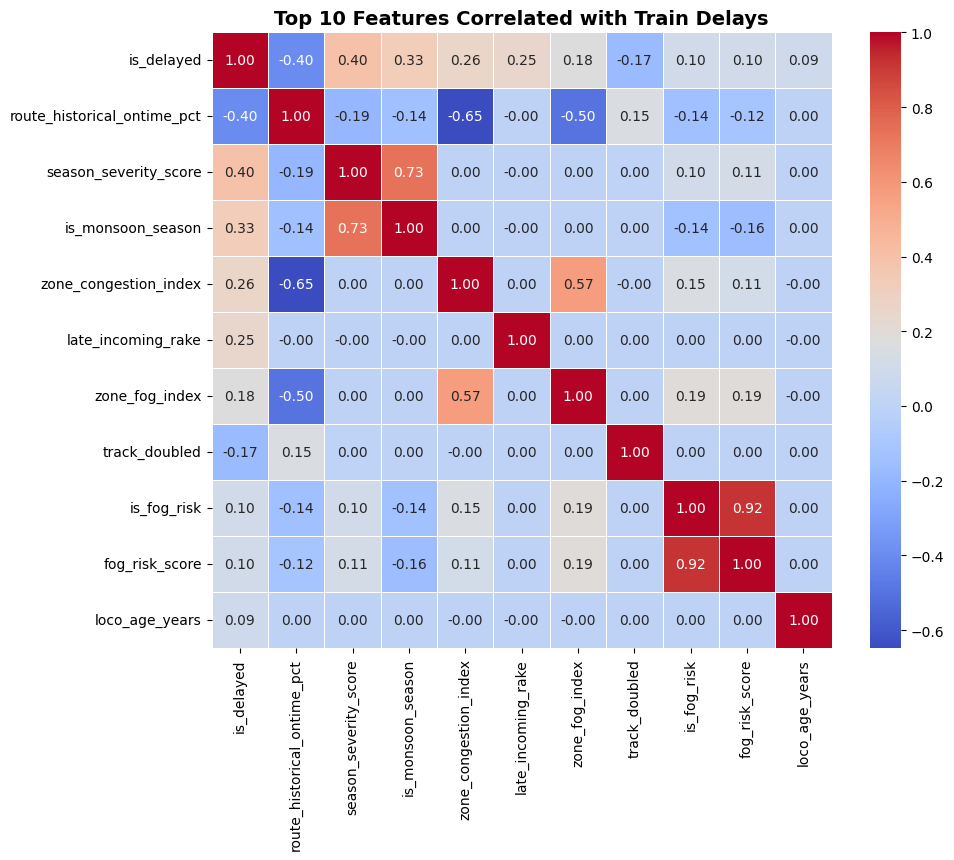

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 10 Features Correlated with Train Delays", fontsize=14, fontweight='bold')
plt.show()

🧠 Hidden Insight: Feature-to-Feature Relationships
This is where your heatmap becomes interview gold. look at how features interact with each other:

1. is_fog_risk vs fog_risk_score = 0.92 (Almost identical!)
These two are basically the same information in different formats. One is binary (yes/no fog), the other is a score. In an interview, say: "I identified multicollinearity — these two features are 92% correlated with each other. Keeping both would add noise to the model. I would drop fog_risk_score and keep only is_fog_risk to reduce redundancy."

2. season_severity_score vs is_monsoon_season = 0.73
Again, highly correlated! Monsoon drives up the severity score. You could potentially drop one of these during feature engineering.

3. zone_congestion_index vs zone_fog_index = 0.57
This tells a real-world story: Foggy zones in North India also tend to be the most congested zones. The problems compound — fog + congestion = maximum delays.

4. zone_congestion_index vs route_historical_ontime_pct = -0.65
The strongest feature-to-feature relationship. It means: Congested zones have terrible on-time history. This makes perfect sense — if a zone is always congested, trains on those routes are historically always late.

From the correlation heatmap, I identified that the top delay predictors are season severity (+0.40), route historical on-time percentage (-0.40), monsoon season (+0.33), zone congestion (+0.26), and late incoming rakes (+0.25). I also identified multicollinearity between is_fog_risk and fog_risk_score (0.92 correlation), which I will address during feature selection to avoid redundant information feeding into the model.